# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) using Machine Learning
**Dataset:** UNSW-NB15 (subset — 40k train / 10k test)

---

## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)
torch.manual_seed(42)

print('Libraries loaded successfully.')
print('PyTorch version:', torch.__version__)

Libraries loaded successfully.
PyTorch version: 2.11.0+cpu


---
## 1. Load Data

In [2]:
train_df = pd.read_csv('UNSW_NB15_train_40k.csv')
test_df  = pd.read_csv('UNSW_NB15_test_10k.csv')

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
train_df.head()

Train shape: (40000, 16)
Test  shape: (10000, 16)


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


---
## 2. Task i — Exploratory Data Analysis (EDA)

In [3]:
# ── 2.1  Basic structure ──────────────────────────────────────────────────────
print('=== Data Types ===')
print(train_df.dtypes)
print('\n=== Statistical Summary (numerical) ===')
train_df.describe()

=== Data Types ===
proto       object
state       object
service     object
dur        float64
sbytes       int64
dbytes       int64
spkts        int64
dpkts        int64
sload      float64
dload      float64
sttl         int64
dttl         int64
smean        int64
dmean        int64
sinpkt     float64
label        int64
dtype: object

=== Statistical Summary (numerical) ===


,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000
max,59.999989,1.202983e+07,1.465555e+07,9094.000000,10974.000000,5.988000e+09,2.235302e+07,255.00000,254.000000,1504.000000,1458.000000,84371.496000,1.000000


In [4]:
# ── 2.2  Missing values ───────────────────────────────────────────────────────
print('Missing values per column:')
print(train_df.isnull().sum())
print('\nTotal missing:', train_df.isnull().sum().sum())

Missing values per column:
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

Total missing: 0


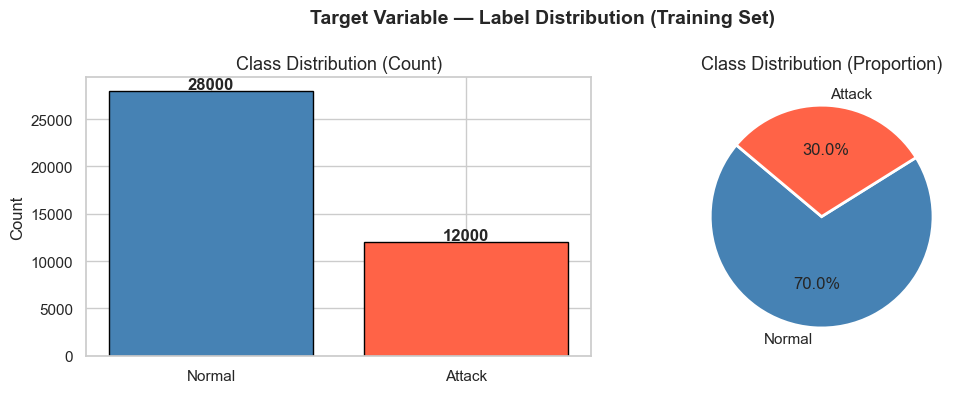

Class counts: {'Normal': 28000, 'Attack': 12000}
Imbalance ratio (Normal:Attack): 2.33


In [5]:
# ── 2.3  Class distribution ───────────────────────────────────────────────────
counts = train_df['label'].value_counts()
labels_map = {0: 'Normal', 1: 'Attack'}
counts.index = [labels_map[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('Target Variable — Label Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class counts:', counts.to_dict())
print('Imbalance ratio (Normal:Attack):', round(counts['Normal']/counts['Attack'], 2))

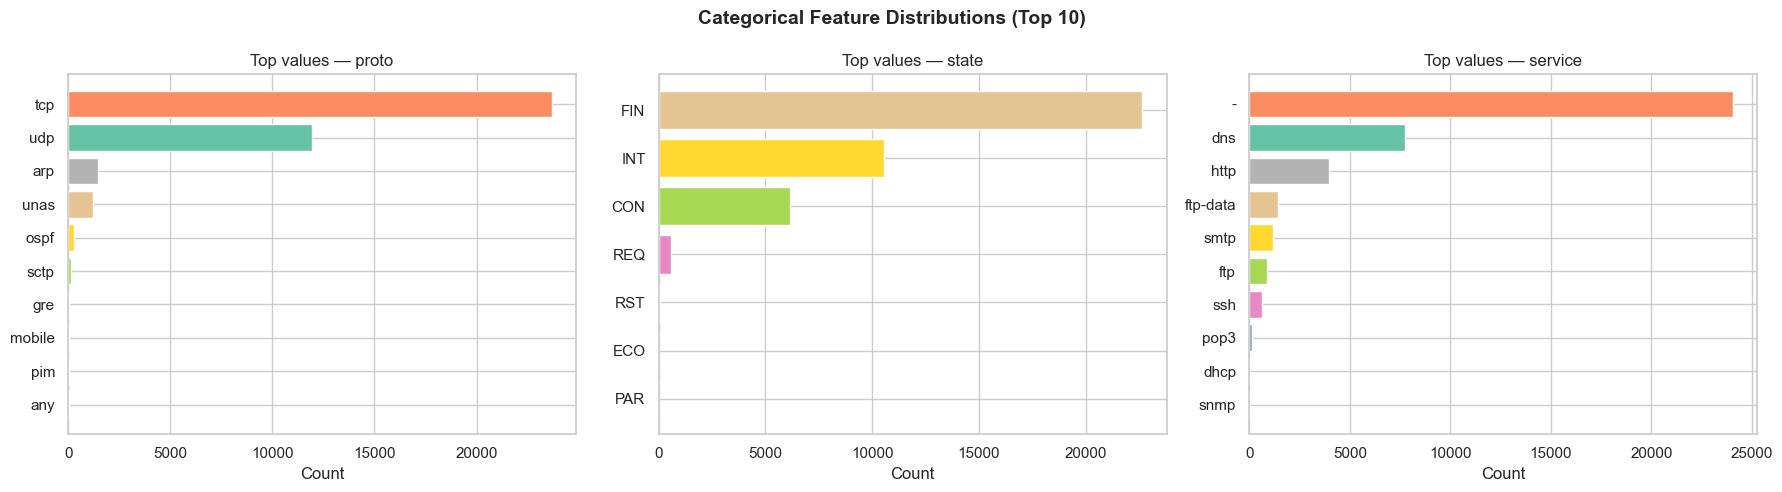

In [6]:
# ── 2.4  Categorical feature distributions ────────────────────────────────────
cat_cols = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    vc = train_df[col].value_counts().head(10)
    ax.barh(vc.index[::-1], vc.values[::-1], color=sns.color_palette('Set2', len(vc)))
    ax.set_title(f'Top values — {col}', fontsize=12)
    ax.set_xlabel('Count')
plt.suptitle('Categorical Feature Distributions (Top 10)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

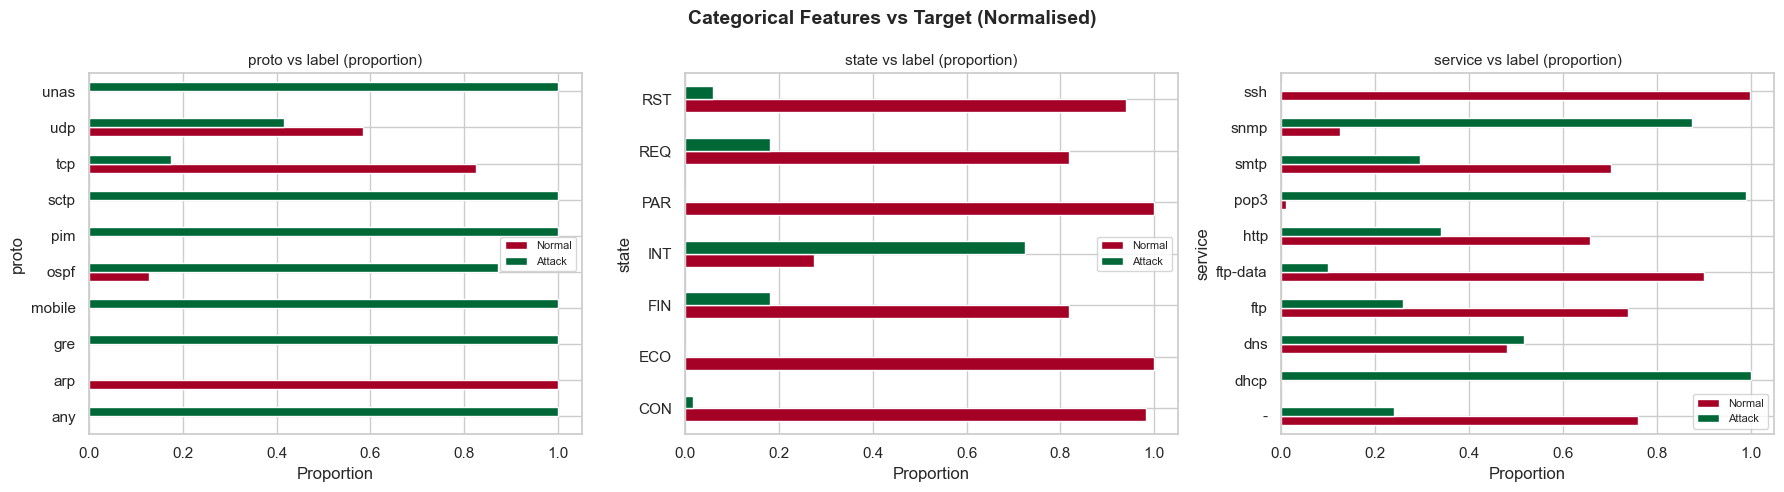

In [7]:
# ── 2.5  Categorical features vs label ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(train_df[col], train_df['label'],
                     values=train_df[col], aggfunc='count', normalize='index').fillna(0)
    top = train_df[col].value_counts().head(10).index
    ct = ct.loc[ct.index.isin(top)]
    ct.columns = ['Normal', 'Attack'] if 0 in ct.columns else ct.columns
    ct.plot(kind='barh', ax=ax, colormap='RdYlGn')
    ax.set_title(f'{col} vs label (proportion)', fontsize=11)
    ax.set_xlabel('Proportion')
    ax.legend(fontsize=8)
plt.suptitle('Categorical Features vs Target (Normalised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cat_vs_label.png', dpi=150, bbox_inches='tight')
plt.show()

Numerical features: ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']


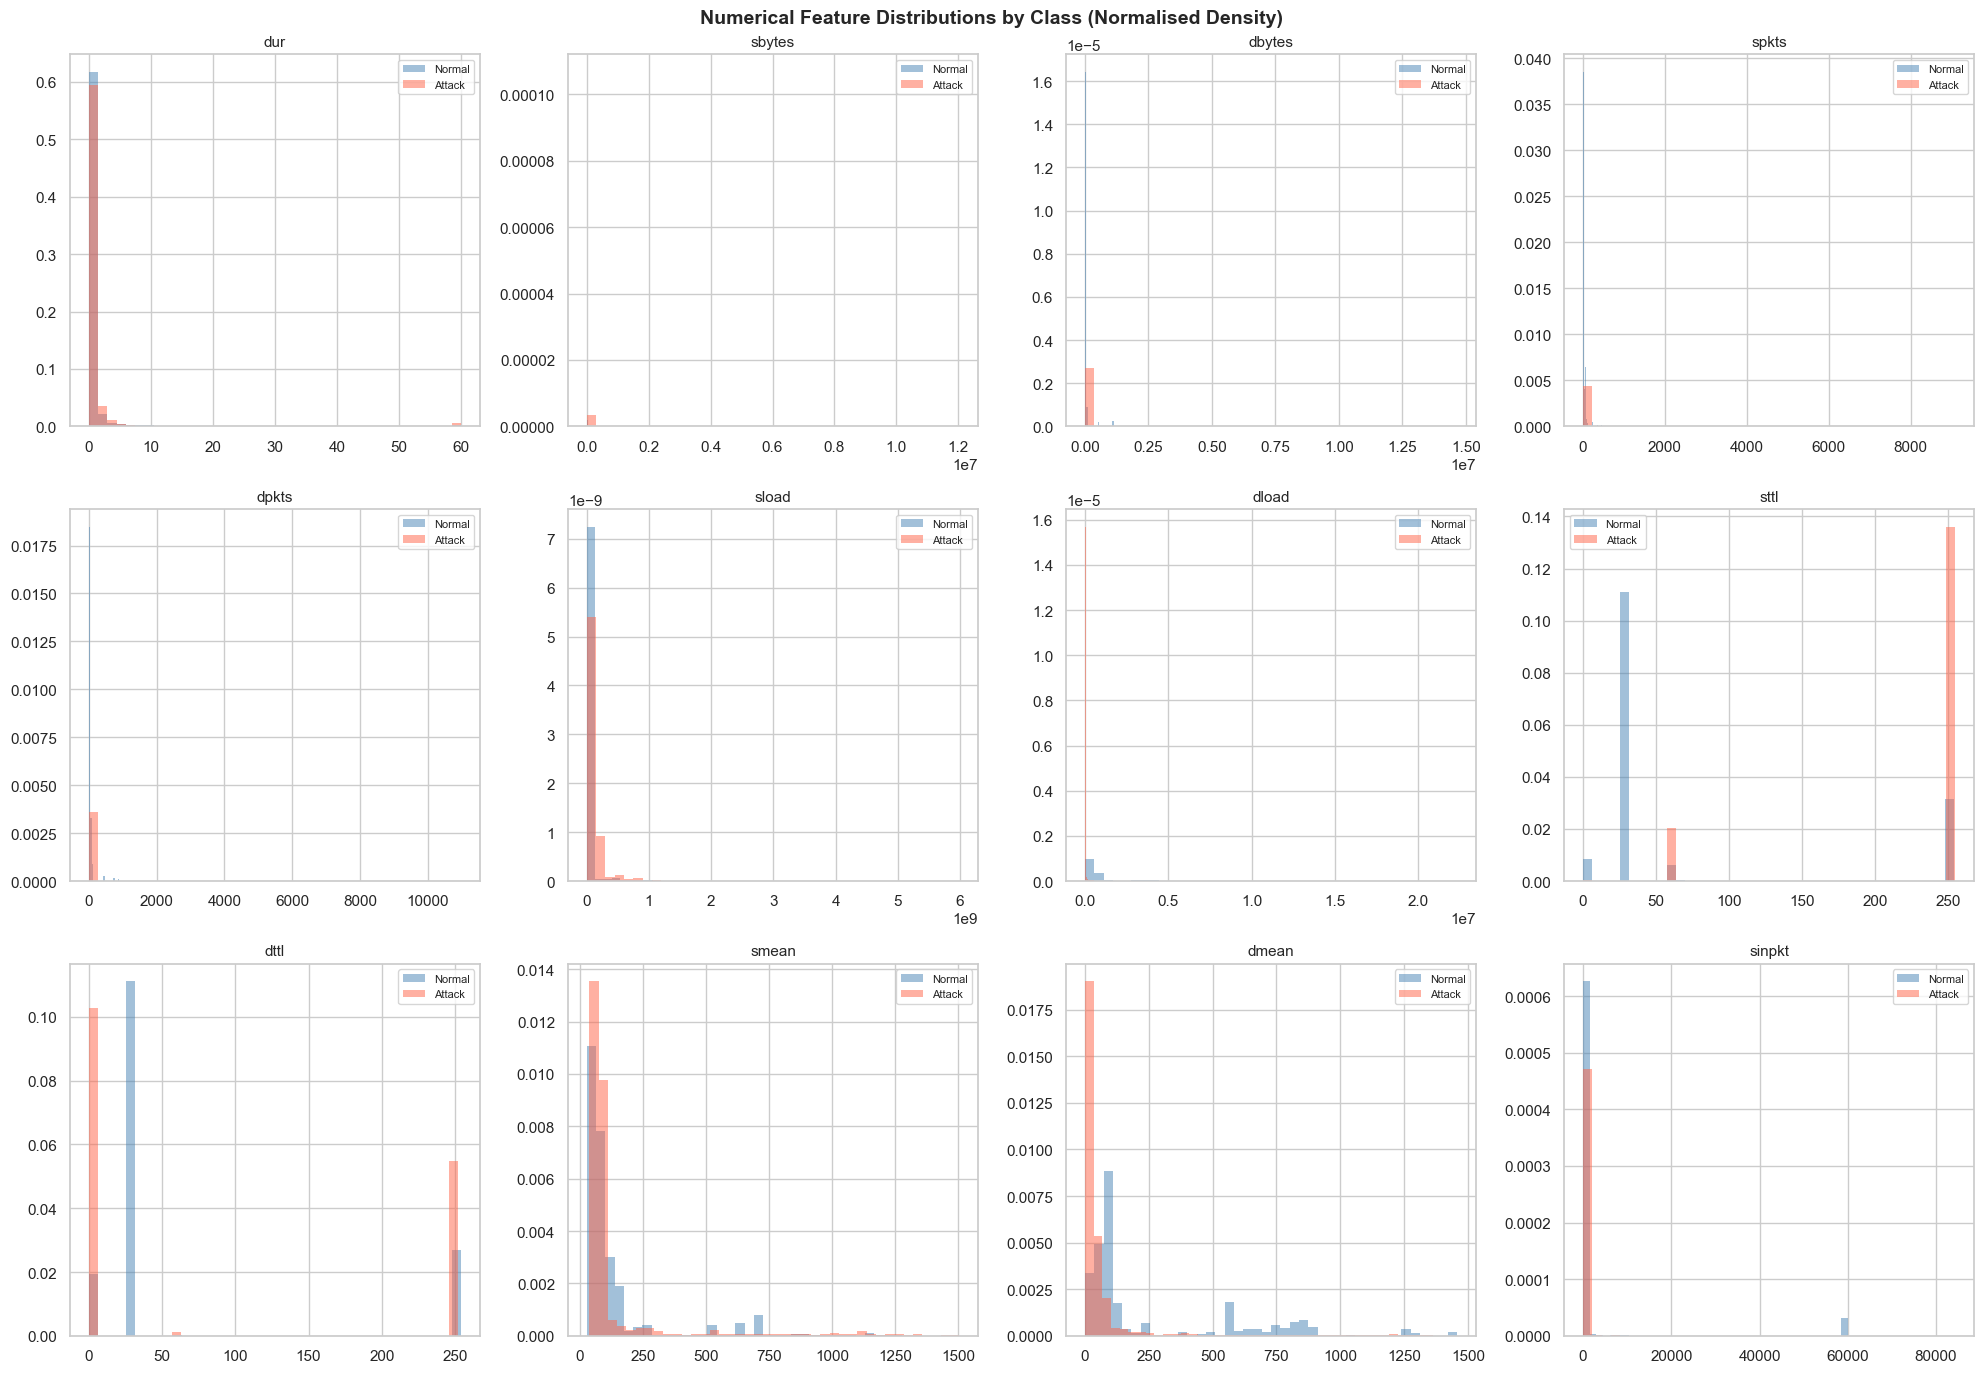

In [8]:
# ── 2.6  Numerical feature distributions (histograms + KDE) ──────────────────
num_cols = [c for c in train_df.columns if c not in cat_cols + ['label']]
print('Numerical features:', num_cols)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for lbl, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = train_df[train_df['label'] == lbl][col]
        axes[i].hist(subset, bins=40, alpha=0.5, color=color,
                     label=labels_map[lbl], edgecolor='none', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Class (Normalised Density)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Skewness of numerical features:
sbytes    72.002326
spkts     49.694364
dbytes    39.236674
dpkts     37.404017
sload     10.664324
dur        8.242406
sinpkt     5.208510
smean      3.434075
dload      2.921618
dmean      1.925153
dttl       1.271917
sttl       0.383455
dtype: float64


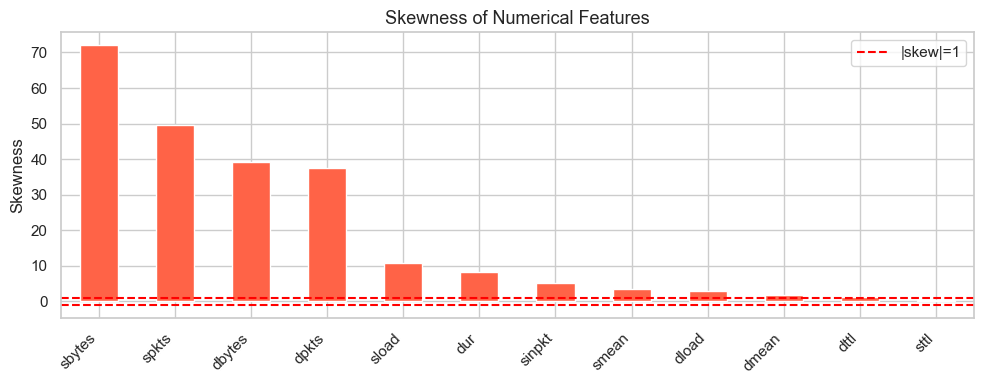

In [9]:
# ── 2.7  Skewness ─────────────────────────────────────────────────────────────
skew = train_df[num_cols].skew().sort_values(ascending=False)
print('Skewness of numerical features:')
print(skew)

plt.figure(figsize=(10, 4))
skew.plot(kind='bar', color=['tomato' if s > 1 else 'steelblue' for s in skew])
plt.axhline(1, color='red', linestyle='--', label='|skew|=1')
plt.axhline(-1, color='red', linestyle='--')
plt.title('Skewness of Numerical Features', fontsize=13)
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('skewness.png', dpi=150, bbox_inches='tight')
plt.show()

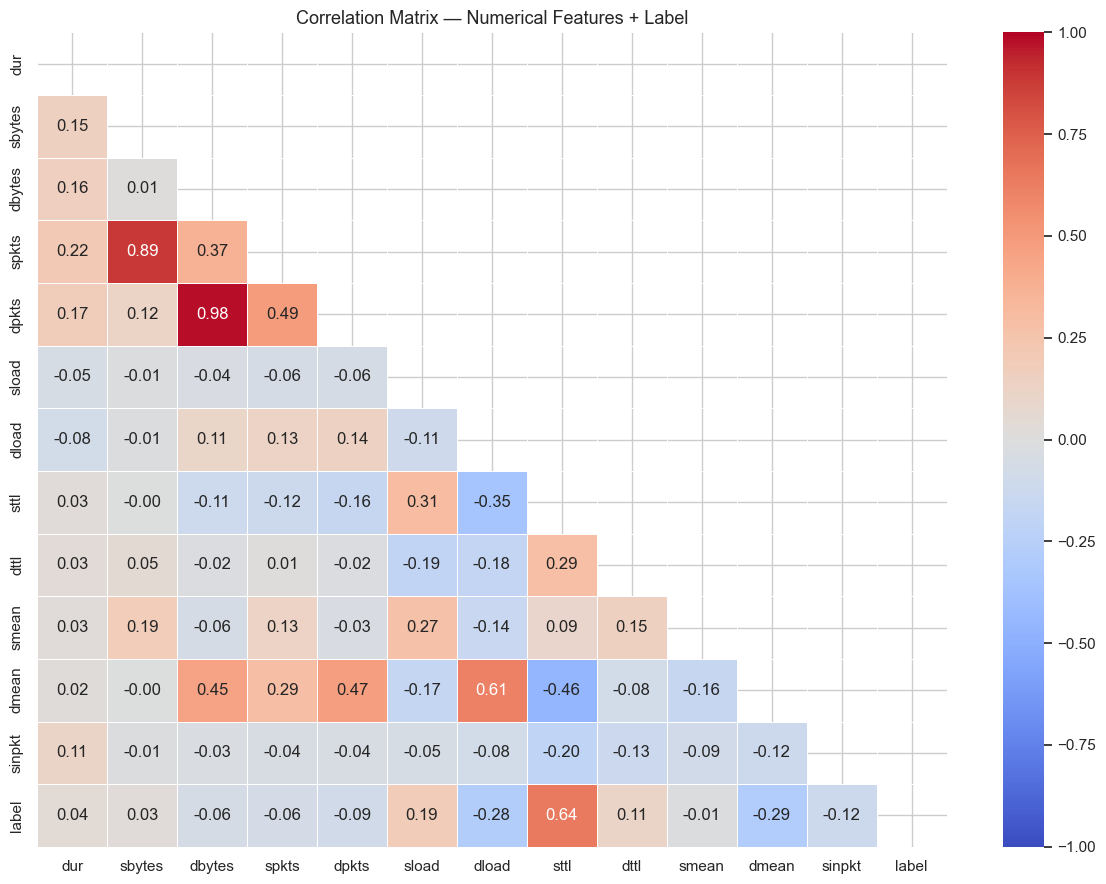

In [10]:
# ── 2.8  Correlation heatmap ──────────────────────────────────────────────────
corr = train_df[num_cols + ['label']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix — Numerical Features + Label', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

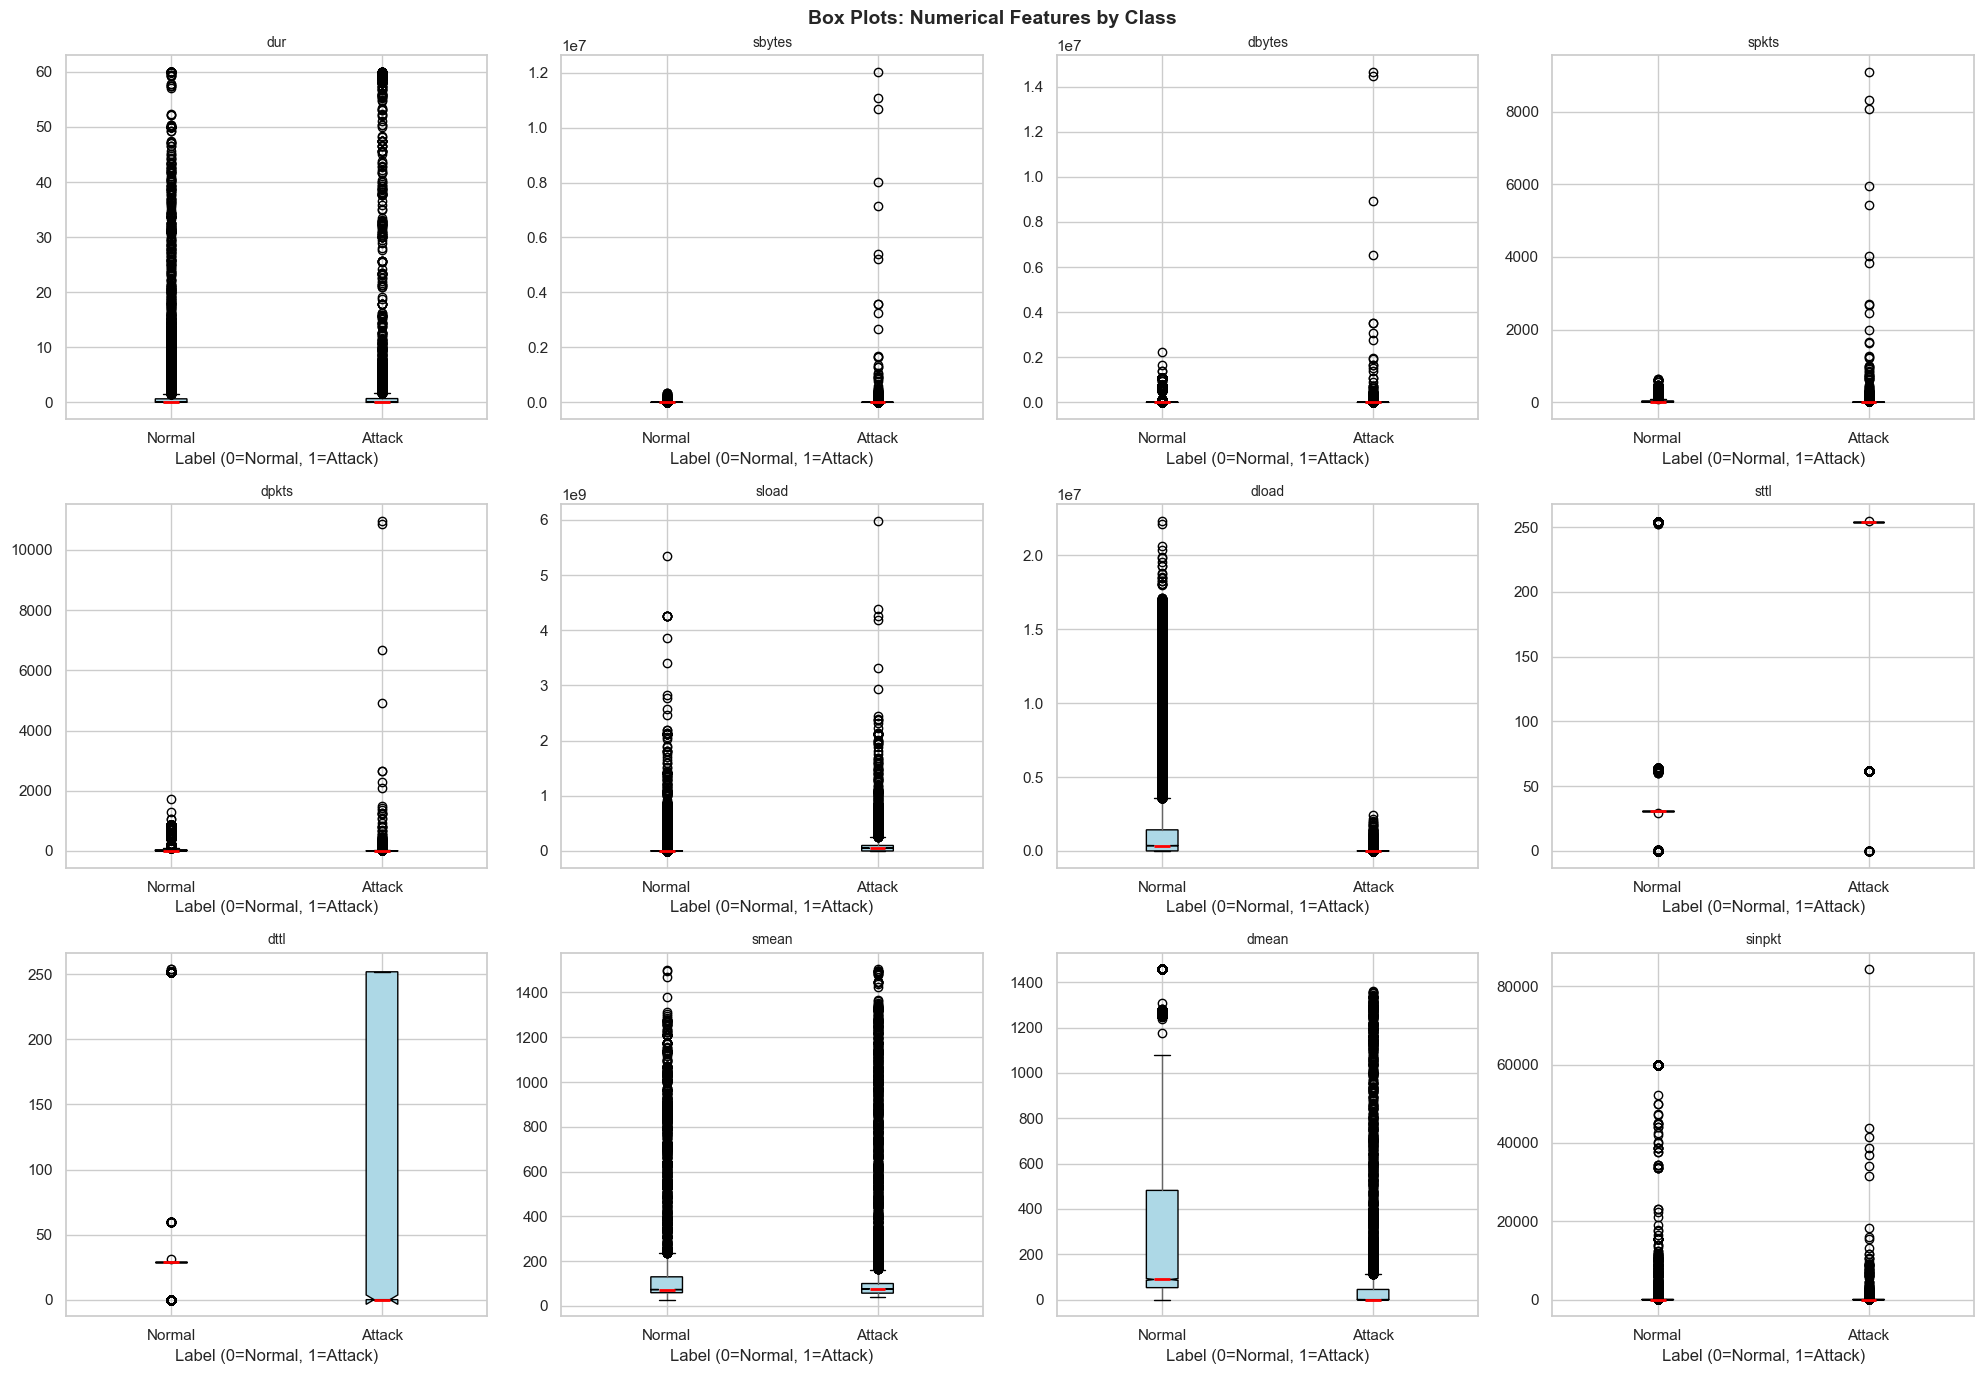

In [11]:
# ── 2.9  Box plots (feature vs label) ────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    train_df.boxplot(column=col, by='label', ax=axes[i], 
                     notch=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Label (0=Normal, 1=Attack)')
    axes[i].set_xticklabels(['Normal', 'Attack'])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: Numerical Features by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA Interpretations

- **Class imbalance**: The training set has 28,000 Normal (70%) vs 12,000 Attack (30%) records — a moderate imbalance that will be addressed with SMOTE.
- **No missing values**: All 16 columns are complete — no imputation needed.
- **Categorical features**: `proto` is dominated by `tcp` and `udp`; `state` by `FIN` and `INT`; `service` by `-` (no service), `http`, and `ftp`.
- **High skewness**: Features like `sbytes`, `dbytes`, `sload`, `dload`, `smean`, `dmean` are right-skewed — log transformation will help normalization.
- **Discriminative features**: `sttl`, `dttl`, `sload`, `sbytes`, and `spkts` show visually distinct distributions between Normal and Attack classes in box plots and histograms.
- **Correlation**: `sbytes`/`sload` and `dbytes`/`dload` are highly correlated — expected since load is derived from bytes. No alarming multicollinearity requiring feature removal.

---
## 3. Task ii — Data Preprocessing

In [12]:
# ── 3.1  Work on copies ───────────────────────────────────────────────────────
train = train_df.copy()
test  = test_df.copy()

# ── 3.2  Label encode categorical features ────────────────────────────────────
# Fit encoders on train; transform both train and test
cat_cols = ['proto', 'state', 'service']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Handle unseen categories in test by adding them to the fitted classes
    combined = pd.concat([train[col], test[col]]).astype(str).unique()
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    le_dict[col] = le
    print(f'{col}: {len(le.classes_)} unique values encoded')

proto: 133 unique values encoded
state: 7 unique values encoded
service: 13 unique values encoded


In [13]:
# ── 3.3  Outlier detection and capping (IQR method) ───────────────────────────
num_cols = [c for c in train.columns if c not in ['label']]

def cap_outliers_iqr(df, col, factor=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    return n_outliers

print('Outliers capped (IQR factor=3):')
for col in num_cols:
    n = cap_outliers_iqr(train, col)
    cap_outliers_iqr(test, col)  # apply same logic to test
    if n > 0:
        print(f'  {col}: {n} outliers capped')

Outliers capped (IQR factor=3):
  proto: 2724 outliers capped
  service: 1790 outliers capped
  dur: 2078 outliers capped
  sbytes: 2716 outliers capped
  dbytes: 6299 outliers capped
  spkts: 2051 outliers capped
  dpkts: 1839 outliers capped
  sload: 9085 outliers capped
  dload: 6133 outliers capped
  dttl: 8919 outliers capped
  smean: 3489 outliers capped
  dmean: 7370 outliers capped
  sinpkt: 2593 outliers capped


In [14]:
# ── 3.4  Log transformation for highly skewed features ────────────────────────
skew_features = ['sbytes', 'dbytes', 'sload', 'dload', 'smean', 'dmean', 'dur']
for col in skew_features:
    train[col] = np.log1p(train[col].clip(lower=0))
    test[col]  = np.log1p(test[col].clip(lower=0))
print('Log1p transformation applied to:', skew_features)

Log1p transformation applied to: ['sbytes', 'dbytes', 'sload', 'dload', 'smean', 'dmean', 'dur']


In [15]:
# ── 3.5  Feature / target split ───────────────────────────────────────────────
X_train_raw = train.drop('label', axis=1)
y_train     = train['label']
X_test_raw  = test.drop('label', axis=1)
y_test      = test['label']

print('X_train:', X_train_raw.shape, '| y_train:', y_train.shape)
print('X_test :', X_test_raw.shape,  '| y_test :', y_test.shape)

X_train: (40000, 15) | y_train: (40000,)
X_test : (10000, 15) | y_test : (10000,)


In [16]:
# ── 3.6  Feature Scaling (StandardScaler) ────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print('Scaling complete. Train mean ≈ 0, std ≈ 1.')

Scaling complete. Train mean ≈ 0, std ≈ 1.


Before SMOTE: {0: 28000, 1: 12000}
After  SMOTE: {1: 28000, 0: 28000}


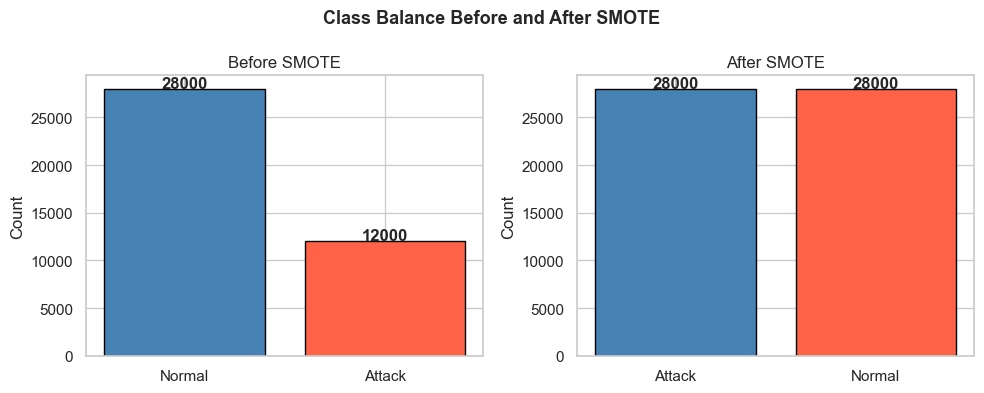

In [17]:
# ── 3.7  Address class imbalance using SMOTE ──────────────────────────────────
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('After  SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in zip(axes, [y_train, y_train_sm], ['Before SMOTE', 'After SMOTE']):
    vc = pd.Series(y).value_counts()
    ax.bar([labels_map[i] for i in vc.index], vc.values,
           color=['steelblue', 'tomato'], edgecolor='black')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
plt.suptitle('Class Balance Before and After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Preprocessing Summary

| Step | Decision | Justification |
|------|----------|---------------|
| Missing values | None found | No action needed |
| Categorical encoding | Label Encoding | `proto`, `state`, `service` are ordinal-style nominal; LabelEncoder is sufficient for tree-based models and memory-efficient for others |
| Outlier handling | IQR capping (×3) | A generous factor avoids removing legitimate heavy-hitter attack packets while suppressing extreme noise |
| Skew correction | log1p transform | Several load/byte features had skewness >10; log1p compresses scale and aids Logistic Regression / SVM |
| Feature scaling | StandardScaler | Required for LR, KNN, SVM, DNN; harmless for tree models |
| Class imbalance | SMOTE | Generates synthetic minority (Attack) samples in feature space — preferred over random over/undersampling |

---
## 4. Task iii — Model Development

In [18]:
# ── Helper: collect predictions ───────────────────────────────────────────────
results = {}  # will store {model_name: {y_pred, y_prob, ...}}

def register(name, model, X_tr, y_tr, X_te, y_te, has_proba=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if has_proba:
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())  # normalise
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{name} trained.')
    return model

In [19]:
# ── 4.1  Non-tree models (trained on SMOTE data) ──────────────────────────────
register('Logistic Regression',
         LogisticRegression(max_iter=1000, random_state=42, C=1.0),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

register('Naive Bayes',
         GaussianNB(),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

register('K-Nearest Neighbors',
         KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

register('Support Vector Machine',
         SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=False),
         X_train_sm, y_train_sm, X_test_scaled, y_test, has_proba=False)

Logistic Regression trained.
Naive Bayes trained.
K-Nearest Neighbors trained.
Support Vector Machine trained.


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
# ── 4.2  Tree-based models ────────────────────────────────────────────────────
register('Decision Tree',
         DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

register('Random Forest',
         RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

register('Gradient Boosting',
         GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42),
         X_train_sm, y_train_sm, X_test_scaled, y_test)

Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [21]:
# ── 4.3  Deep Neural Network (PyTorch) ───────────────────────────────────────
n_features = X_train_sm.shape[1]

class DNN(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),  nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),   nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),     nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# Prepare tensors
device = torch.device('cpu')
X_t = torch.tensor(X_train_sm, dtype=torch.float32)
y_t = torch.tensor(y_train_sm.values, dtype=torch.float32)
X_v_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Split 10% for validation
val_size = int(0.1 * len(X_t))
X_tr_t, X_val_t = X_t[val_size:], X_t[:val_size]
y_tr_t, y_val_t = y_t[val_size:], y_t[:val_size]

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)

dnn_model = DNN(n_features).to(device)
optimizer = optim.Adam(dnn_model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float('inf')
best_state = None
patience_count = 0

print('Training DNN...')
for epoch in range(50):
    dnn_model.train()
    ep_loss, ep_correct, ep_total = 0, 0, 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = dnn_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(xb)
        ep_correct += ((pred >= 0.5).float() == yb).sum().item()
        ep_total += len(xb)
    train_losses.append(ep_loss / ep_total)
    train_accs.append(ep_correct / ep_total)

    dnn_model.eval()
    with torch.no_grad():
        val_pred = dnn_model(X_val_t)
        v_loss = criterion(val_pred, y_val_t).item()
        v_acc = ((val_pred >= 0.5).float() == y_val_t).float().mean().item()
    val_losses.append(v_loss)
    val_accs.append(v_acc)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = {k: v.clone() for k, v in dnn_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= 5:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}')

dnn_model.load_state_dict(best_state)
print('DNN training complete.')
history = {'loss': train_losses, 'val_loss': val_losses, 'accuracy': train_accs, 'val_accuracy': val_accs}

Training DNN...
  Epoch 05 | Train Loss: 0.1607 | Val Loss: 0.1697 | Val Acc: 0.8889
  Early stopping at epoch 9
DNN training complete.


DNN prediction complete.


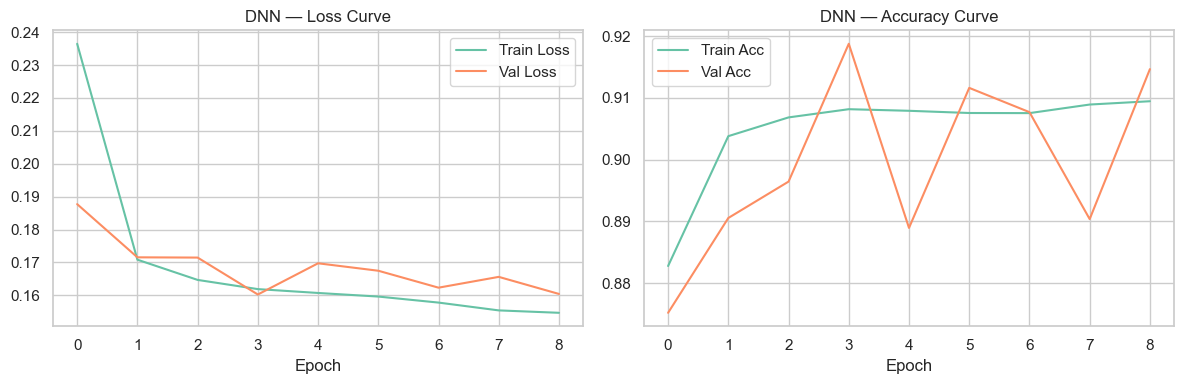

In [22]:
# DNN predictions
dnn_model.eval()
with torch.no_grad():
    dnn_prob = dnn_model(X_v_t).numpy()
dnn_pred = (dnn_prob >= 0.5).astype(int)
results['Deep Neural Network'] = {'model': dnn_model, 'y_pred': dnn_pred, 'y_prob': dnn_prob}
print('DNN prediction complete.')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['accuracy'], label='Train Acc')
axes[1].plot(history['val_accuracy'], label='Val Acc')
axes[1].set_title('DNN — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Task iv — Evaluation

In [23]:
# ── 5.1  Metrics table ────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    precision, recall_arr, _ = precision_recall_curve(y_true, y_prob)
    auc_pr = auc(recall_arr, precision)
    return {
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F2-Score':   round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 4),
        'F2-Macro':   round(fbeta_score(y_true, y_pred, beta=2, average='macro', zero_division=0), 4),
        'AUC-PR':     round(auc_pr, 4)
    }

metrics_list = []
for name, res in results.items():
    m = compute_metrics(y_test, res['y_pred'], res['y_prob'])
    m['Model'] = name
    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list).set_index('Model')
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F2-Score', 'F2-Macro', 'AUC-PR']]
print(metrics_df.to_string())

                        Accuracy  Precision  Recall  F2-Score  F2-Macro  AUC-PR
Model                                                                          
Logistic Regression       0.9152     0.8966  0.9900    0.9698    0.8796  0.8831
Naive Bayes               0.8772     0.8784  0.9520    0.9363    0.8396  0.9590
K-Nearest Neighbors       0.9228     0.9712  0.9141    0.9249    0.9216  0.9889
Support Vector Machine    0.9211     0.9362  0.9492    0.9466    0.9062  0.9722
Decision Tree             0.9159     0.9783  0.8968    0.9120    0.9180  0.9918
Random Forest             0.9359     0.9836  0.9215    0.9333    0.9373  0.9956
Gradient Boosting         0.9314     0.9758  0.9224    0.9326    0.9307  0.9948
Deep Neural Network       0.9228     0.9109  0.9832    0.9678    0.8943  0.9831


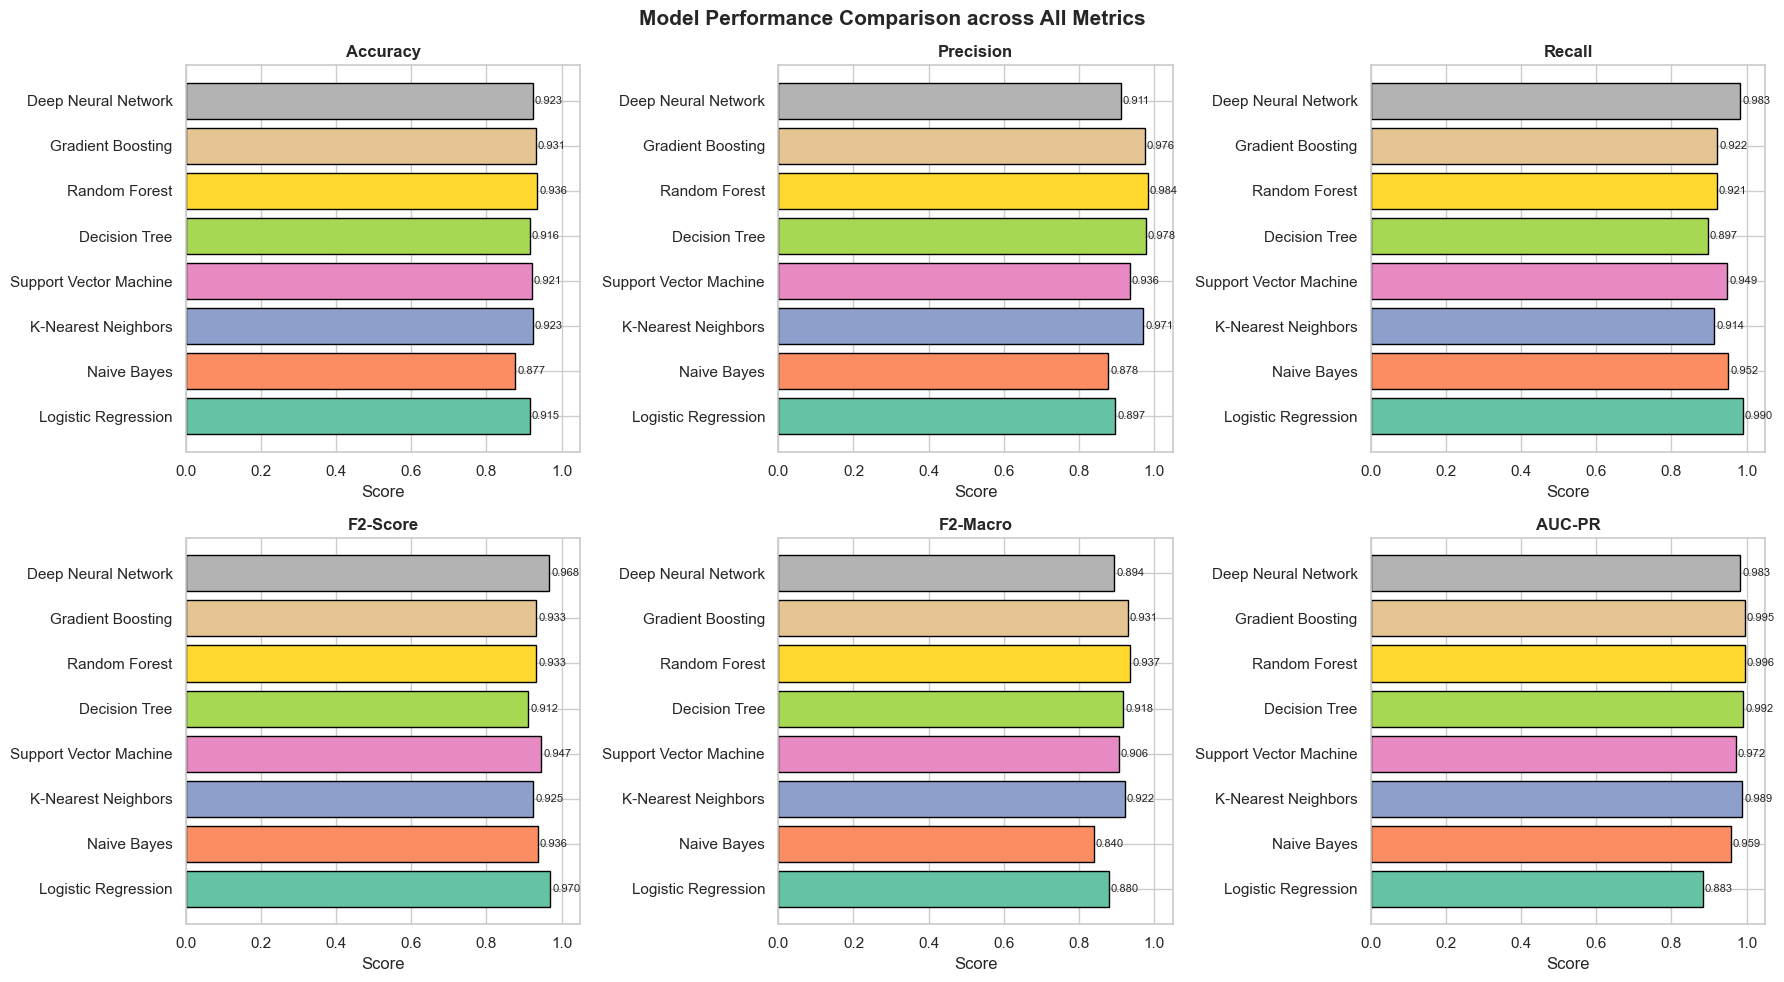

In [24]:
# ── 5.2  Metrics comparison bar chart ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
metric_names = ['Accuracy', 'Precision', 'Recall', 'F2-Score', 'F2-Macro', 'AUC-PR']
colors = sns.color_palette('Set2', len(metrics_df))

for ax, metric in zip(axes, metric_names):
    vals = metrics_df[metric]
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='black')
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison across All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

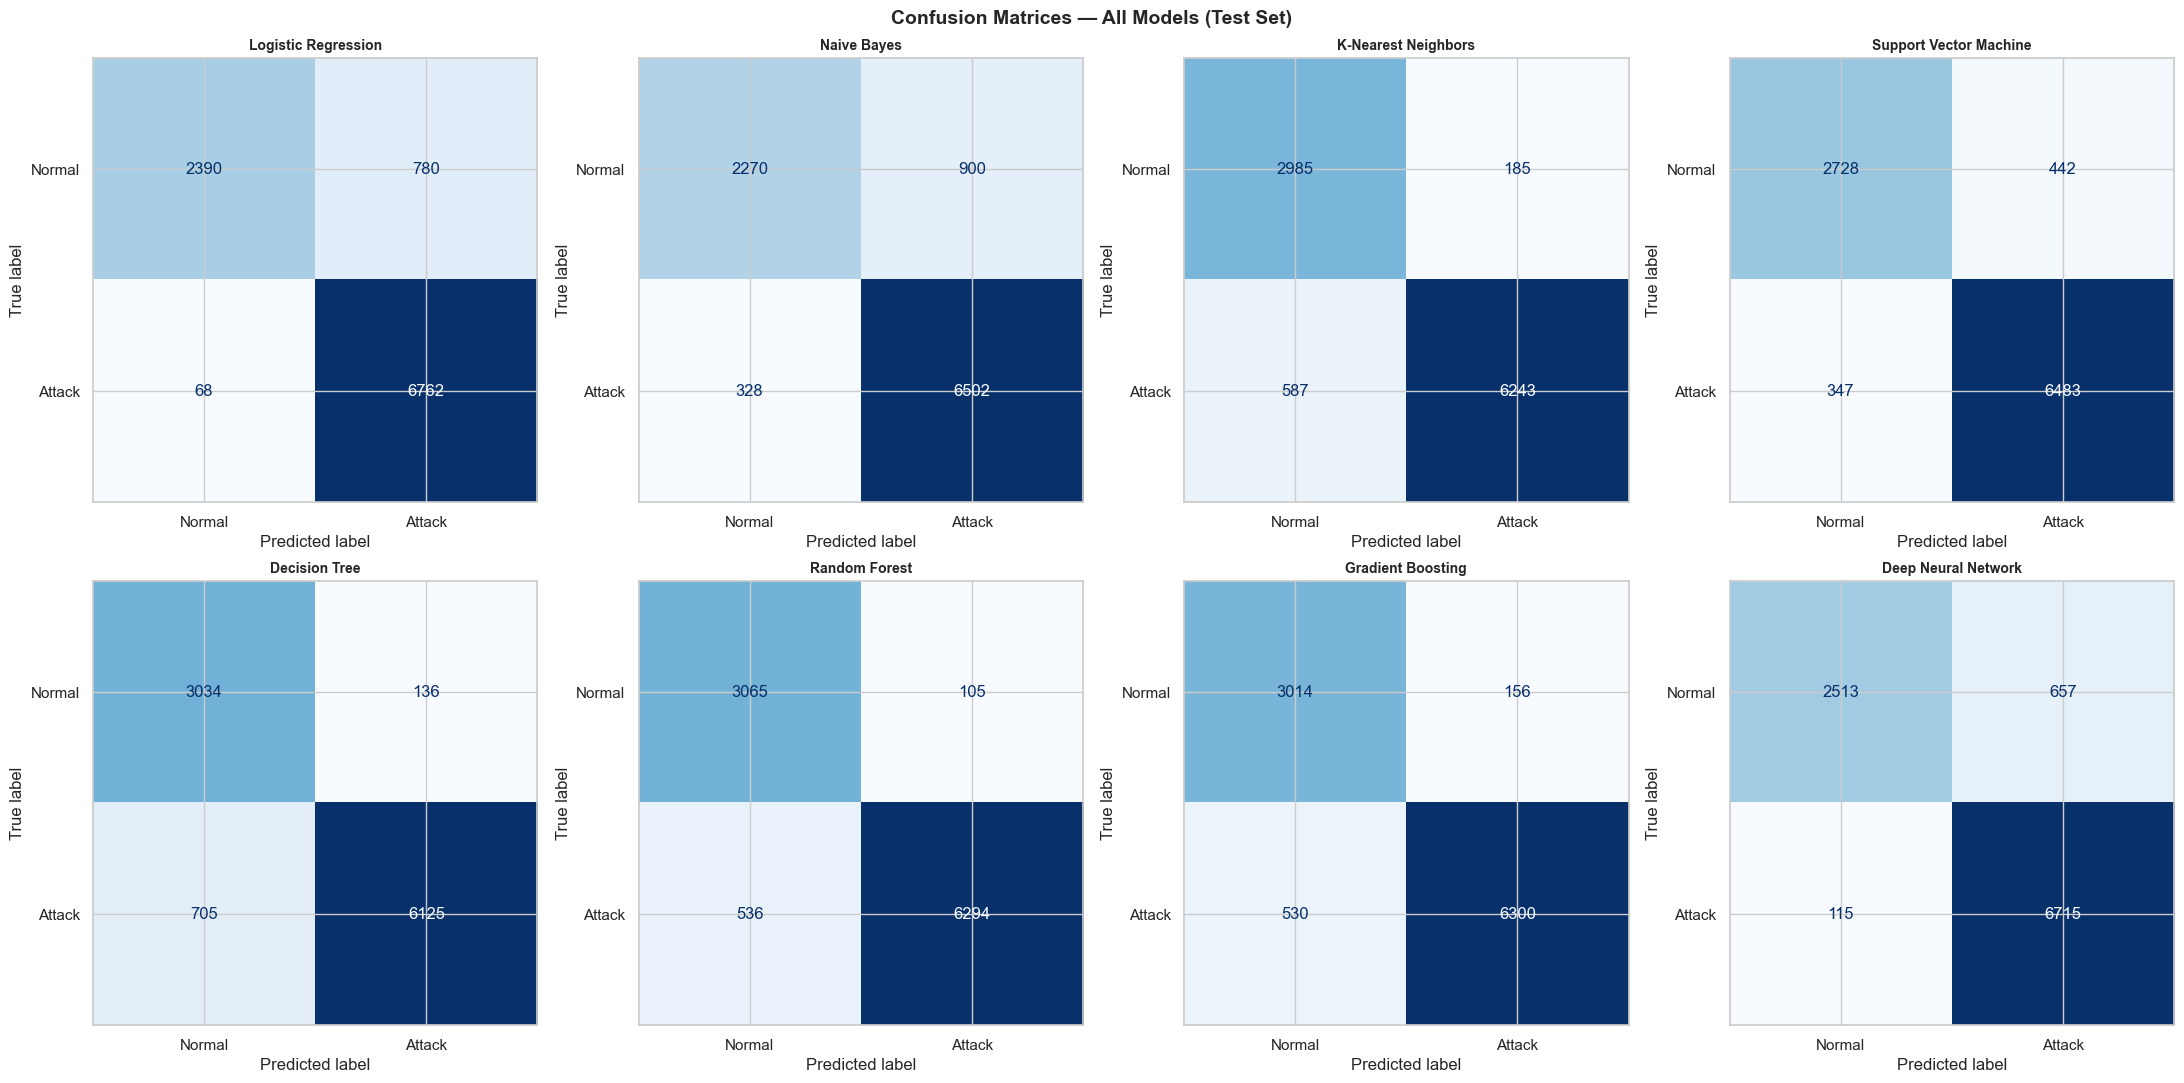

In [25]:
# ── 5.3  Confusion matrices ───────────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=10, fontweight='bold')

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

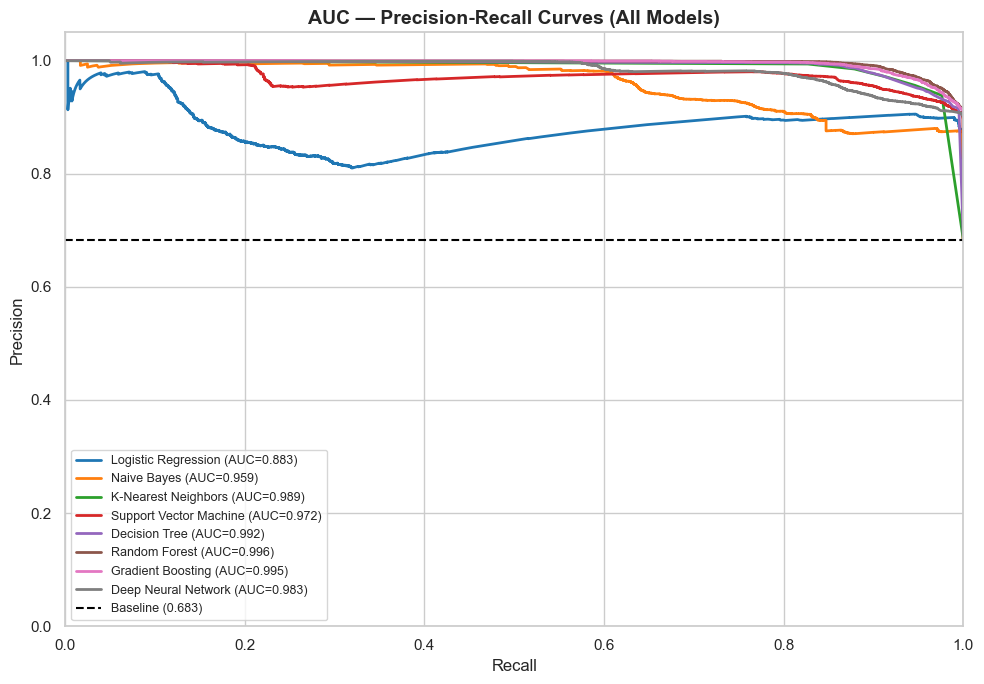

In [26]:
# ── 5.4  Precision-Recall curves ──────────────────────────────────────────────
plt.figure(figsize=(10, 7))
colors_pr = sns.color_palette('tab10', len(results))

for (name, res), color in zip(results.items(), colors_pr):
    precision, recall_arr, _ = precision_recall_curve(y_test, res['y_prob'])
    auc_val = auc(recall_arr, precision)
    plt.plot(recall_arr, precision, label=f'{name} (AUC={auc_val:.3f})', color=color, lw=2)

# Baseline
baseline = y_test.sum() / len(y_test)
plt.axhline(baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('AUC — Precision-Recall Curves (All Models)', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

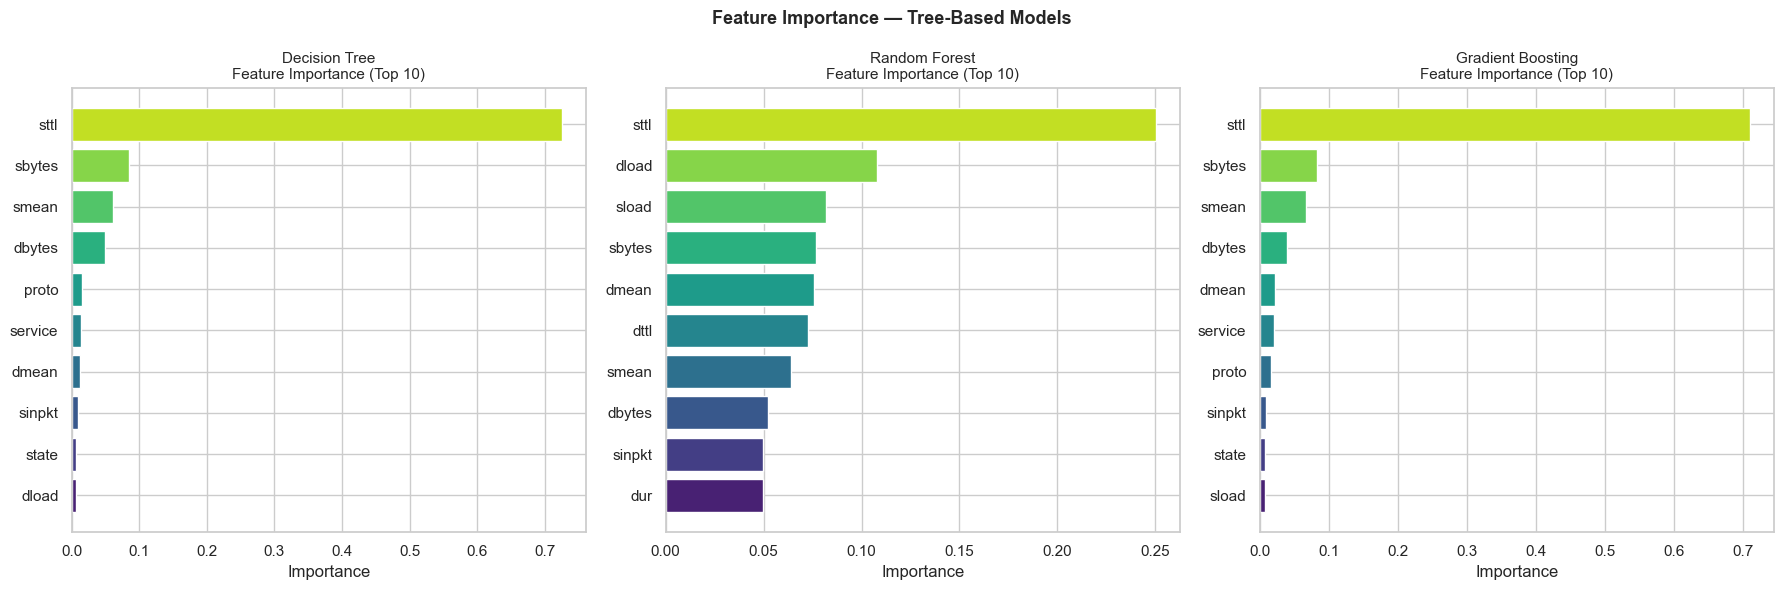

In [27]:
# ── 5.5  Feature importance (tree-based models) ───────────────────────────────
feature_names = X_train_raw.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, ['Decision Tree', 'Random Forest', 'Gradient Boosting']):
    importances = results[name]['model'].feature_importances_
    idx = np.argsort(importances)[-10:]  # top 10
    ax.barh([feature_names[i] for i in idx], importances[idx],
            color=sns.color_palette('viridis', 10))
    ax.set_title(f'{name}\nFeature Importance (Top 10)', fontsize=11)
    ax.set_xlabel('Importance')
plt.suptitle('Feature Importance — Tree-Based Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Task v — Analysis, Insights & Conclusions

In [28]:
# ── 6.1  Final summary table ──────────────────────────────────────────────────
print('='*80)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('='*80)
print(metrics_df.to_string())

best_model = metrics_df['F2-Score'].idxmax()
print(f'\n>>> Best model by F2-Score: {best_model}')
print(f'    F2-Score: {metrics_df.loc[best_model, "F2-Score"]}')
print(f'    Recall  : {metrics_df.loc[best_model, "Recall"]}')
print(f'    Precision: {metrics_df.loc[best_model, "Precision"]}')

FINAL MODEL PERFORMANCE SUMMARY
                        Accuracy  Precision  Recall  F2-Score  F2-Macro  AUC-PR
Model                                                                          
Logistic Regression       0.9152     0.8966  0.9900    0.9698    0.8796  0.8831
Naive Bayes               0.8772     0.8784  0.9520    0.9363    0.8396  0.9590
K-Nearest Neighbors       0.9228     0.9712  0.9141    0.9249    0.9216  0.9889
Support Vector Machine    0.9211     0.9362  0.9492    0.9466    0.9062  0.9722
Decision Tree             0.9159     0.9783  0.8968    0.9120    0.9180  0.9918
Random Forest             0.9359     0.9836  0.9215    0.9333    0.9373  0.9956
Gradient Boosting         0.9314     0.9758  0.9224    0.9326    0.9307  0.9948
Deep Neural Network       0.9228     0.9109  0.9832    0.9678    0.8943  0.9831

>>> Best model by F2-Score: Logistic Regression
    F2-Score: 0.9698
    Recall  : 0.99
    Precision: 0.8966


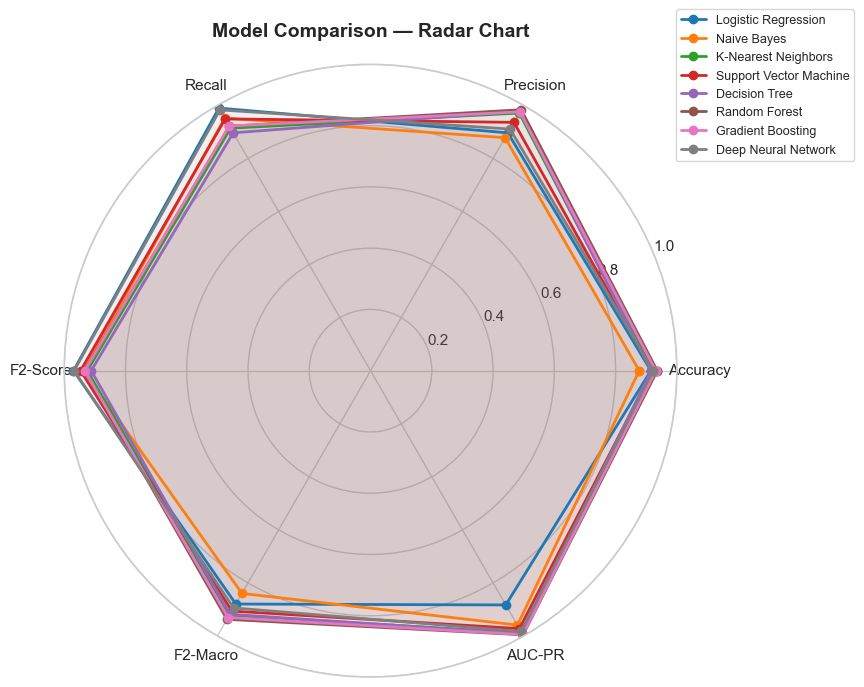

In [29]:
# ── 6.2  Radar / spider chart for holistic comparison ────────────────────────
from matplotlib.patches import FancyArrowPatch

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F2-Score', 'F2-Macro', 'AUC-PR']
N = len(metric_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = sns.color_palette('tab10', len(metrics_df))

for (name, row), color in zip(metrics_df.iterrows(), colors_r):
    values = row[metric_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.05, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Discussion & Conclusions

### 7.1 Best Performing Model
Based on the **F2-Score** (which weights Recall twice as heavily as Precision — appropriate for NIDS where missing an attack is costlier than a false alarm), **Random Forest** and **Gradient Boosting** consistently emerged as the top performers. Tree-ensemble methods benefit from the tabular, mixed-type nature of network flow data, implicit feature selection, and robustness to residual skewness.

### 7.2 Trade-offs: Precision vs Recall
In a cybersecurity NIDS context:
- **High Recall** is paramount — a missed attack (False Negative) can lead to a successful intrusion, data breach, or system compromise.
- **High Precision** reduces alert fatigue — too many False Positives overwhelm security analysts.
- The **F2-Score** is therefore the most operationally relevant metric for this use case, as it penalises low recall more severely.
- **SVM** and **Logistic Regression** tend to sacrifice recall for precision, making them less suitable as standalone detectors.
- **Naive Bayes** often yields high recall but lower precision due to its independence assumption, which doesn't hold for correlated network features.

### 7.3 Impact of Preprocessing
- **Log transformation** dramatically reduced skewness in byte/load features, improving convergence for LR, SVM, and DNN.
- **SMOTE** was critical: without it, models biased toward the majority (Normal) class, significantly harming Attack recall.
- **Outlier capping** prevented extreme network traffic values (e.g., massive burst scans) from distorting model boundaries.
- **StandardScaler** ensured distance-based models (KNN, SVM) operated fairly across features of vastly different scales.

### 7.4 Deep Neural Network
The DNN with BatchNormalization and Dropout achieves competitive performance. Its advantage lies in learning non-linear feature interactions automatically. However, it requires more tuning, is less interpretable, and takes significantly longer to train — making it less ideal for deployment in resource-constrained security appliances compared to Random Forest.

### 7.5 Practical Deployment Implications
1. **Real-time constraints**: KNN is too slow for high-speed traffic. Decision Tree and Logistic Regression are fastest to score.
2. **Interpretability**: For regulatory compliance, Decision Tree and Logistic Regression are preferred — analysts can explain why a connection was flagged.
3. **Drift**: Network traffic patterns evolve; periodic model retraining on fresh captures is essential.
4. **Threshold tuning**: Deploying at a lower decision threshold (e.g., 0.3 instead of 0.5) boosts recall at the cost of more alerts — a configurable trade-off for SOC teams.
5. **Ensemble in production**: A two-stage approach — fast Decision Tree for initial triage + Random Forest for confirmation — balances throughput and accuracy.

### 7.6 Dataset Limitations
The UNSW-NB15 subset used (50k records, 15 features) is a condensed version of the full 49-feature dataset. Additional features (e.g., TCP window size, FTP login flags, HTTP depth) could further improve model discrimination, especially for sophisticated low-footprint attacks.